# 🌲 Analisis Produksi RBDPO dengan Random Forest
**PT Industri Nabati Lestari (PT INL) — Skripsi**

---
### Pipeline Penelitian
1. Install & Import Library
2. Upload & Load Data (JSON + Excel)  
3. Preprocessing & Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Training Random Forest
6. Evaluasi Model (R², RMSE, MAE, MAPE)
7. Feature Importance (MDI + Permutation)
8. Ringkasan & Interpretasi untuk Skripsi


---
## 📦 Cell 1 — Install & Import Library

In [30]:
import sys, subprocess, os, re, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Install ke kernel aktif (JupyterLab-safe)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openpyxl", "scikit-learn"])

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', None)

%matplotlib inline
plt.rcParams['figure.figsize']    = (13, 5)
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

SEED = 42
np.random.seed(SEED)

print('library selesai di install')

library selesai di install


---
## 📁 Cell 2 — Upload File JSON

In [32]:
# ── Load Data JSON dari folder ../data ───────────────────────────────────────
# Resolusi path relatif terhadap lokasi notebook, bukan working directory
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
JSON_DIR     = os.path.join(NOTEBOOK_DIR, "..", "data")
JSON_DIR     = os.path.normpath(JSON_DIR)   # bersihkan path (hapus ..)

# Validasi folder exists
if not os.path.isdir(JSON_DIR):
    raise FileNotFoundError(f"Folder data tidak ditemukan: {JSON_DIR}")

# Scan file JSON
REQUIRED_FILES = {"laporan_produksi.json", "stok_cpo.json", "target_produksi.json"}
json_files     = sorted(glob.glob(os.path.join(JSON_DIR, "*.json")))
found_files    = {os.path.basename(f) for f in json_files}

# Cek kelengkapan file
missing = REQUIRED_FILES - found_files
if missing:
    raise FileNotFoundError(f"File JSON tidak ditemukan di {JSON_DIR}:\n  ❌ {', '.join(sorted(missing))}")

print(f" {len(json_files)} file JSON ditemukan di: {JSON_DIR}")
for f in json_files:
    size_kb = os.path.getsize(f) / 1024
    print(f"    {os.path.basename(f):35s} ({size_kb:.1f} KB)")

 5 file JSON ditemukan di: D:\chatbot inl\data
    dataset_cpo.json                    (342.1 KB)
    dataset_cpo_reuters.json            (919.5 KB)
    laporan_produksi.json               (623.9 KB)
    stok_cpo.json                       (1786.8 KB)
    target_produksi.json                (18.3 KB)


---
## 📁 Cell 3 — Upload File Excel (2021–2023)

In [33]:
# ── Load Data Excel dari folder ../data/excel ─────────────────────────────────
EXCEL_DIR = os.path.normpath(os.path.join(NOTEBOOK_DIR, "..", "data", "excel"))

if not os.path.isdir(EXCEL_DIR):
    raise FileNotFoundError(f"Folder excel tidak ditemukan: {EXCEL_DIR}")

excel_files = sorted(glob.glob(os.path.join(EXCEL_DIR, "*.xlsx")))

if not excel_files:
    raise FileNotFoundError(f"Tidak ada file .xlsx di: {EXCEL_DIR}")

print(f" {len(excel_files)} file Excel ditemukan di: {EXCEL_DIR}")
for f in excel_files:
    size_kb = os.path.getsize(f) / 1024
    print(f"    {os.path.basename(f):45s} ({size_kb:.1f} KB)")

 56 file Excel ditemukan di: D:\chatbot inl\data\excel
    01. DAILY REPORT PRODUCTION JANUARI 2025 (STOP PLANT).xlsx (897.7 KB)
    01. DAILY REPORT PRODUCTION JANUARI 2026.xlsx (2315.0 KB)
    01. Production Report -Januari 2022.xlsx      (793.0 KB)
    01.DAILY REPORT PRODUCTION JANUARI 2024.xlsx  (253.6 KB)
    01.DAILY REPORT PRODUCTION JANUARY 2023.xlsx  (158.5 KB)
    02. DAILY REPORT PRODUCTION FEBRUARI 2025.xlsx (936.4 KB)
    02. DAILY REPORT PRODUCTION FEBRUARI 2026.xlsx (2305.3 KB)
    02. Production Report -Februari 2022.xlsx     (1202.2 KB)
    02.DAILY REPORT PRODUCTION FEBRUARI 2023.xlsx (232.7 KB)
    02.DAILY REPORT PRODUCTION FEBRUARI 2024.xlsx (233.5 KB)
    03. DAILY REPORT PRODUCTION MARET 2025.xlsx   (944.8 KB)
    03. DAILY REPORT PRODUCTION MARET 2026.xlsx   (2303.3 KB)
    03. Production Report -Maret 2022.xlsx        (426.6 KB)
    03.DAILY REPORT PRODUCTION MARET 2023.xlsx    (238.5 KB)
    03.DAILY REPORT PRODUCTION MARET 2024.xlsx    (239.7 KB)
    04. DAI

---
## 🔧 Cell 4 — Load & Preprocessing Data JSON

In [34]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        raw = json.load(f)
    return raw['data'] if isinstance(raw, dict) and 'data' in raw else raw

# ── Load semua JSON ──────────────────────────────────────────────────────────
PATH_LAPORAN = os.path.join(JSON_DIR, 'laporan_produksi.json')
PATH_STOK    = os.path.join(JSON_DIR, 'stok_cpo.json')
PATH_TARGET  = os.path.join(JSON_DIR, 'target_produksi.json')

lap_records    = load_json(PATH_LAPORAN)
stok_records   = load_json(PATH_STOK)
target_records = load_json(PATH_TARGET)

print(f' laporan_produksi : {len(lap_records):>5} records')
print(f' stok_cpo         : {len(stok_records):>5} records')
print(f' target_produksi  : {len(target_records):>5} records')

# ── Agregasi laporan produksi per bulan ──────────────────────────────────────
realisasi_d = defaultdict(float)  # RBDPO produk_hasil
cpo_d       = defaultdict(float)  # CPO bahan_olah = bahan baku masuk
hari_olah_d = defaultdict(float)  # Hari Olah = hari operasi
pfad_d      = defaultdict(float)  # PFAD produk_hasil = produk samping

for x in lap_records:
    item = x.get('item_produksi', {})
    name = item.get('name', '')
    kat  = item.get('kategori', '')
    b    = x['tanggal'][:7]
    try:
        qty = float(x['qty'])
    except:
        continue
    if name == 'RBDPO'    and kat == 'produk_hasil': realisasi_d[b] += qty
    elif name == 'CPO'    and kat == 'bahan_olah'  : cpo_d[b]       += qty
    elif name == 'Hari Olah'                       : hari_olah_d[b] += qty
    elif name == 'PFAD'   and kat == 'produk_hasil': pfad_d[b]       += qty

# ── Target RKAP ──────────────────────────────────────────────────────────────
target_d = defaultdict(float)
for x in target_records:
    try:
        if x.get('uraian', {}).get('nama') == 'RKAP':
            target_d[x['tanggal'][:7]] += float(x['value'])
    except:
        continue

# Fix anomali satuan target Juli–Agustus 2025 (58,900 harusnya 58,900,000)
for b in list(target_d.keys()):
    if target_d[b] < 1_000_000:
        target_d[b] *= 1000

# ── Stok CPO: fitur bulanan dari data harian ─────────────────────────────────
stok_raw = defaultdict(list)
for x in stok_records:
    try:
        stok_raw[x['tanggal'][:7]].append(float(x['qty']))
    except:
        continue

stok_d = {}
for b, vals in stok_raw.items():
    arr = np.array(vals)
    stok_d[b] = {
        'stok_rata2'      : float(np.mean(arr)),
        'stok_max'        : float(np.max(arr)),
        'stok_std'        : float(np.std(arr)),
        'stok_hari_aktif' : int(np.sum(arr > 0)),
    }

print(f'\n Ringkasan data dari JSON:')
print(f'   Realisasi RBDPO : {len(realisasi_d)} bulan ({sorted(realisasi_d)[0]} – {sorted(realisasi_d)[-1]})')
print(f'   CPO Consume     : {len(cpo_d)} bulan')
print(f'   Hari Olah       : {len(hari_olah_d)} bulan')
print(f'   Target RKAP     : {len(target_d)} bulan')
print(f'   Stok CPO        : {len(stok_d)} bulan ({sorted(stok_d)[0]} – {sorted(stok_d)[-1]})')


 laporan_produksi :  1020 records
 stok_cpo         :  2792 records
 target_produksi  :    35 records

 Ringkasan data dari JSON:
   Realisasi RBDPO : 20 bulan (2024-01 – 2025-09)
   CPO Consume     : 20 bulan
   Hari Olah       : 21 bulan
   Target RKAP     : 21 bulan
   Stok CPO        : 17 bulan (2024-12 – 2026-04)


---
## 🔧 Cell 5 — Parser Excel (Deteksi Otomatis 2021–2023)

In [35]:
# ── Mapping nama bulan Indonesia ─────────────────────────────────────────────
BULAN_MAP = {
    'januari':1,'februari':2,'maret':3,'april':4,'mei':5,'juni':6,
    'juli':7,'agustus':8,'september':9,'oktober':10,'november':11,'desember':12,
    'january':1,'february':2,'march':3,'may':5,'june':6,'july':7,
    'august':8,'october':10,'december':12,
    'jan':1,'feb':2,'mar':3,'apr':4,'jun':6,'jul':7,
    'aug':8,'agu':8,'sep':9,'oct':10,'okt':10,'nov':11,'dec':12,'des':12,
}

def parse_periode(filename):
    fname = os.path.basename(filename).lower()
    year_match = re.search(r'(202\d)', fname)
    year  = int(year_match.group(1)) if year_match else None
    month = None
    for nama, num in sorted(BULAN_MAP.items(), key=lambda x: -len(x[0])):
        if nama in fname and len(nama) > 2:
            month = num
            break
    return year, month

def find_sheet(xl):
    skip = ['sheet','trace','utility','summary','yearly','v.1']
    for name in xl.sheet_names:
        n = name.lower()
        if not any(x in n for x in skip):
            return name
    return xl.sheet_names[0]

def find_row(df, keywords, max_row=120, col_range=6):
    if isinstance(keywords, str): keywords = [keywords]
    for r in range(min(df.shape[0], max_row)):
        for c in range(min(df.shape[1], col_range)):
            cell = str(df.iloc[r, c]).strip().lower()
            if any(kw.lower() in cell for kw in keywords):
                return r
    return None

def get_daily(df, row, col_start=5, max_days=31):
    vals = []
    for c in range(col_start, col_start + max_days):
        if c >= df.shape[1]: break
        try:
            v = float(df.iloc[row, c])
            vals.append(0.0 if np.isnan(v) else v)
        except: vals.append(0.0)
    return vals

def get_total(df, row, col_start=5, max_days=31):
    daily    = get_daily(df, row, col_start, max_days)
    expected = sum(daily)
    if expected == 0: return 0.0
    for c in range(col_start + max_days, col_start + max_days + 20):
        if c >= df.shape[1]: break
        try:
            v = float(df.iloc[row, c])
            if not np.isnan(v) and abs(v - expected) / (expected + 1) < 0.05:
                return v
        except: continue
    return expected

def extract_excel(filepath):
    year, month = parse_periode(filepath)
    if not year or not month:
        return None
    # Lewati file tahun 2024+ (sudah ada di JSON)
    if year >= 2024:
        return None

    xl  = pd.ExcelFile(filepath)
    sht = find_sheet(xl)
    df  = xl.parse(sht, header=None)
    CS  = 5  # kolom start — konsisten semua tahun

    row_rd    = find_row(df, ['Running Days'])
    row_rbdpo = find_row(df, ['RbdPO'])
    row_cpo   = find_row(df, ['CPO Consume Total','CPO Consume Poram','CPO Consume'])
    row_ffa   = find_row(df, ['- FFA','% FFA','FFA'])
    row_pfad  = find_row(df, ['PFAD'])
    row_hari  = find_row(df, ['Running Days'])  # Hari operasi = Running Days

    rd_vals   = get_daily(df, row_rd, CS) if row_rd is not None else []
    hari_ops  = int(sum(1 for v in rd_vals if v == 1.0))

    rbdpo_total = get_total(df, row_rbdpo, CS) if row_rbdpo is not None else 0.0
    cpo_total   = get_total(df, row_cpo,   CS) if row_cpo   is not None else 0.0
    pfad_total  = get_total(df, row_pfad,  CS) if row_pfad  is not None else 0.0
    ffa_vals    = [v for v in get_daily(df, row_ffa, CS) if 1 < v < 8] if row_ffa is not None else []
    ffa_avg     = float(np.mean(ffa_vals)) if ffa_vals else 0.0
    yield_pct   = (rbdpo_total / cpo_total * 100) if cpo_total > 0 else 0.0

    return {
        'bulan'           : f'{year}-{month:02d}',
        'realisasi_rbdpo' : round(rbdpo_total, 2),
        'cpo_consume'     : round(cpo_total,   2),
        'hari_olah'       : hari_ops * 3,  # Running Days × 3 lini
        'pfad_total'      : round(pfad_total, 2),
        'yield_rbdpo'     : round(yield_pct, 4),
        'ffa_avg'         : round(ffa_avg,   4),
        'sumber'          : 'excel',
    }

# ── Proses semua file Excel ──────────────────────────────────────────────────
excel_files = sorted(glob.glob(os.path.join(EXCEL_DIR, '*.xlsx')))
print(f' Memproses {len(excel_files)} file Excel...\n')

excel_rows, errors = [], []
for fpath in excel_files:
    try:
        result = extract_excel(fpath)
        if result:
            excel_rows.append(result)
            print(f'   {result["bulan"]} | RBDPO: {result["realisasi_rbdpo"]:>15,.0f} | '
                  f'Hari: {result["hari_olah"]:>4} | Yield: {result["yield_rbdpo"]:.2f}%')
        else:
            print(f'    {os.path.basename(fpath)} — dilewati (tahun 2024+ atau gagal parse)')
    except Exception as e:
        errors.append((os.path.basename(fpath), str(e)))
        print(f'   {os.path.basename(fpath)}: {e}')

df_excel = pd.DataFrame(excel_rows) if excel_rows else pd.DataFrame()
if not df_excel.empty:
    df_excel['bulan'] = pd.to_datetime(df_excel['bulan'])
    df_excel = df_excel.sort_values('bulan').drop_duplicates('bulan').reset_index(drop=True)
    print(f'\n Berhasil: {len(df_excel)} bulan dari Excel ({df_excel["bulan"].min().strftime("%b %Y")} – {df_excel["bulan"].max().strftime("%b %Y")})')
else:
    print('  Tidak ada data Excel yang berhasil diproses (mungkin semua 2024+)')


 Memproses 56 file Excel...

    01. DAILY REPORT PRODUCTION JANUARI 2025 (STOP PLANT).xlsx — dilewati (tahun 2024+ atau gagal parse)
    01. DAILY REPORT PRODUCTION JANUARI 2026.xlsx — dilewati (tahun 2024+ atau gagal parse)
   2022-01 | RBDPO:      41,759,500 | Hari:   84 | Yield: 94.82%
    01.DAILY REPORT PRODUCTION JANUARI 2024.xlsx — dilewati (tahun 2024+ atau gagal parse)
   2023-01 | RBDPO:      26,688,160 | Hari:   63 | Yield: 94.54%
    02. DAILY REPORT PRODUCTION FEBRUARI 2025.xlsx — dilewati (tahun 2024+ atau gagal parse)
    02. DAILY REPORT PRODUCTION FEBRUARI 2026.xlsx — dilewati (tahun 2024+ atau gagal parse)
   2022-02 | RBDPO:      41,759,500 | Hari:   84 | Yield: 94.82%
   2023-02 | RBDPO:      72,605,498 | Hari:   84 | Yield: 94.63%
    02.DAILY REPORT PRODUCTION FEBRUARI 2024.xlsx — dilewati (tahun 2024+ atau gagal parse)
    03. DAILY REPORT PRODUCTION MARET 2025.xlsx — dilewati (tahun 2024+ atau gagal parse)
    03. DAILY REPORT PRODUCTION MARET 2026.xlsx — dilew

---
## 🔗 Cell 6 — Gabungkan Semua Sumber & Feature Engineering

In [36]:
# ── Bangun rows dari JSON (base: 2024–2025) ──────────────────────────────────
rows_json = []
bulan_json = sorted(set(realisasi_d) & set(target_d))
for b in bulan_json:
    row = {
        'bulan'           : b,
        'realisasi_rbdpo' : realisasi_d[b],
        'cpo_consume'     : cpo_d.get(b, np.nan),
        'hari_olah'       : hari_olah_d.get(b, np.nan),
        'pfad_total'      : pfad_d.get(b, np.nan),
        'yield_rbdpo'     : (realisasi_d[b]/cpo_d[b]*100) if cpo_d.get(b,0)>0 else 0.0,
        'ffa_avg'         : 0.0,  # tidak tersedia di JSON
        'target_rkap'     : target_d[b],
        'sumber'          : 'json',
    }
    if b in stok_d:
        row.update(stok_d[b])
        row['stok_imputed'] = False
    else:
        row.update({'stok_rata2':np.nan,'stok_max':np.nan,
                    'stok_std':np.nan,'stok_hari_aktif':np.nan})
        row['stok_imputed'] = True
    rows_json.append(row)

df_json = pd.DataFrame(rows_json)
df_json['bulan'] = pd.to_datetime(df_json['bulan'])

# ── Gabungkan dengan Excel (2021–2023) ───────────────────────────────────────
if not df_excel.empty:
    # Tambahkan kolom yang tidak ada di Excel
    df_excel_aug = df_excel.copy()
    df_excel_aug['target_rkap']    = np.nan
    df_excel_aug['stok_rata2']     = np.nan
    df_excel_aug['stok_max']       = np.nan
    df_excel_aug['stok_std']       = np.nan
    df_excel_aug['stok_hari_aktif']= np.nan
    df_excel_aug['stok_imputed']   = True
    df_excel_aug['ffa_avg']        = df_excel_aug.get('ffa_avg', 0.0)

    # Isi target RKAP Excel dengan median dari JSON (asumsi stabil)
    median_target = df_json['target_rkap'].median()
    df_excel_aug['target_rkap'] = median_target

    df_all = pd.concat([df_excel_aug, df_json], ignore_index=True)
else:
    df_all = df_json.copy()
    print('  Tidak ada data Excel — menggunakan JSON saja')

df_all = df_all.sort_values('bulan').drop_duplicates('bulan').reset_index(drop=True)

# ── Imputasi stok dengan interpolasi linear ──────────────────────────────────
for col in ['stok_rata2','stok_max','stok_std','stok_hari_aktif']:
    df_all[col] = df_all[col].interpolate(method='linear', limit_direction='both')
df_all['stok_std']   = df_all['stok_std'].fillna(0)
df_all['target_rkap']= df_all['target_rkap'].fillna(df_all['target_rkap'].median())

# ── Feature engineering ──────────────────────────────────────────────────────
df_all['bulan_ke']       = df_all['bulan'].dt.month
df_all['kuartal']        = df_all['bulan'].dt.quarter
df_all['tahun']          = df_all['bulan'].dt.year
df_all['realisasi_prev'] = df_all['realisasi_rbdpo'].shift(1).fillna(0)
df_all['cpo_prev']       = df_all['cpo_consume'].shift(1).fillna(df_all['cpo_consume'].median())
df_all['hari_olah_prev'] = df_all['hari_olah'].shift(1).fillna(df_all['hari_olah'].median())
df_all['cpo_per_hari']   = df_all['cpo_consume'] / (df_all['hari_olah'] + 1)

# Pastikan tidak ada NaN di kolom fitur penting
df_all['hari_olah']  = df_all['hari_olah'].fillna(df_all['hari_olah'].median())
df_all['cpo_consume']= df_all['cpo_consume'].fillna(df_all['cpo_consume'].median())
df_all['pfad_total'] = df_all['pfad_total'].fillna(0)
df_all['ffa_avg']    = df_all['ffa_avg'].fillna(df_all['ffa_avg'].median())

n_total   = len(df_all)
n_excel   = int((df_all['sumber']=='excel').sum()) if 'sumber' in df_all.columns else 0
n_json    = int((df_all['sumber']=='json').sum()) if 'sumber' in df_all.columns else n_total
n_imputed = int(df_all['stok_imputed'].sum())

print(f' Dataset final gabungan:')
print(f'   Total bulan    : {n_total}')
print(f'   Dari Excel     : {n_excel} bulan (2021–2023)')
print(f'   Dari JSON      : {n_json} bulan (2024–2025)')
print(f'   Stok imputasi  : {n_imputed} bulan')
print(f'   Rentang        : {df_all["bulan"].min().strftime("%b %Y")} – {df_all["bulan"].max().strftime("%b %Y")}')
print(f'\n Preview dataset:')
display(df_all[['bulan','sumber','hari_olah','cpo_consume','realisasi_rbdpo',
                'yield_rbdpo','stok_rata2','target_rkap','stok_imputed']].head(10))


 Dataset final gabungan:
   Total bulan    : 49
   Dari Excel     : 29 bulan (2021–2023)
   Dari JSON      : 20 bulan (2024–2025)
   Stok imputasi  : 40 bulan
   Rentang        : Mar 2020 – Sep 2025

 Preview dataset:


,bulan,sumber,hari_olah,cpo_consume,realisasi_rbdpo,yield_rbdpo,stok_rata2,target_rkap,stok_imputed
0,2020-03-01,excel,0.00,"837,154.61",0.00,0.00,"1,403.67","58,900,000.00",True
1,2021-03-01,excel,0.00,"1,106,832.64",0.00,0.00,"1,403.67","58,900,000.00",True
2,2021-10-01,excel,93.00,"54,292,828.00","51,703,800.00",95.23,"1,403.67","58,900,000.00",True
3,2021-11-01,excel,90.00,"49,733,807.00","47,408,400.00",95.32,"1,403.67","58,900,000.00",True
4,2021-12-01,excel,60.00,"29,768,361.00","28,253,650.00",94.91,"1,403.67","58,900,000.00",True
5,2022-01-01,excel,84.00,"44,039,043.00","41,759,500.00",94.82,"1,403.67","58,900,000.00",True
6,2022-02-01,excel,84.00,"44,039,043.00","41,759,500.00",94.82,"1,403.67","58,900,000.00",True
7,2022-03-01,excel,93.00,"48,712,630.00","46,213,430.00",94.87,"1,403.67","58,900,000.00",True
8,2022-04-01,excel,84.00,"53,908,100.00","51,312,240.00",95.18,"1,403.67","58,900,000.00",True
9,2022-05-01,excel,66.00,"43,662,423.00","41,537,420.00",95.13,"1,403.67","58,900,000.00",True


---
## 📊 Cell 7 — Exploratory Data Analysis (EDA)

In [39]:
# ── 7.1 Statistik deskriptif ─────────────────────────────────────────────────
print(' STATISTIK DESKRIPTIF')
print('='*60)
display(df_all[['realisasi_rbdpo','cpo_consume','hari_olah',
                'yield_rbdpo','stok_rata2','target_rkap']].describe().T)


 STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
realisasi_rbdpo,49.00,"26,359,196.96","18,041,784.04",0.00,"13,450,366.00","23,517,297.00","41,759,500.00","72,605,498.00"
cpo_consume,49.00,"27,815,322.94","18,930,669.74",0.00,"14,557,768.00","24,626,089.00","43,680,296.00","76,727,694.00"
hari_olah,49.00,62.18,35.50,0.00,39.00,66.00,90.00,135.00
yield_rbdpo,49.00,81.16,33.51,0.00,94.49,94.77,95.18,97.94
stok_rata2,49.00,"1,518.29",402.96,855.27,"1,403.67","1,403.67","1,403.67","3,209.70"
target_rkap,49.00,"57,810,204.08","6,395,022.96","25,740,000.00","58,900,000.00","58,900,000.00","58,900,000.00","68,200,000.00"


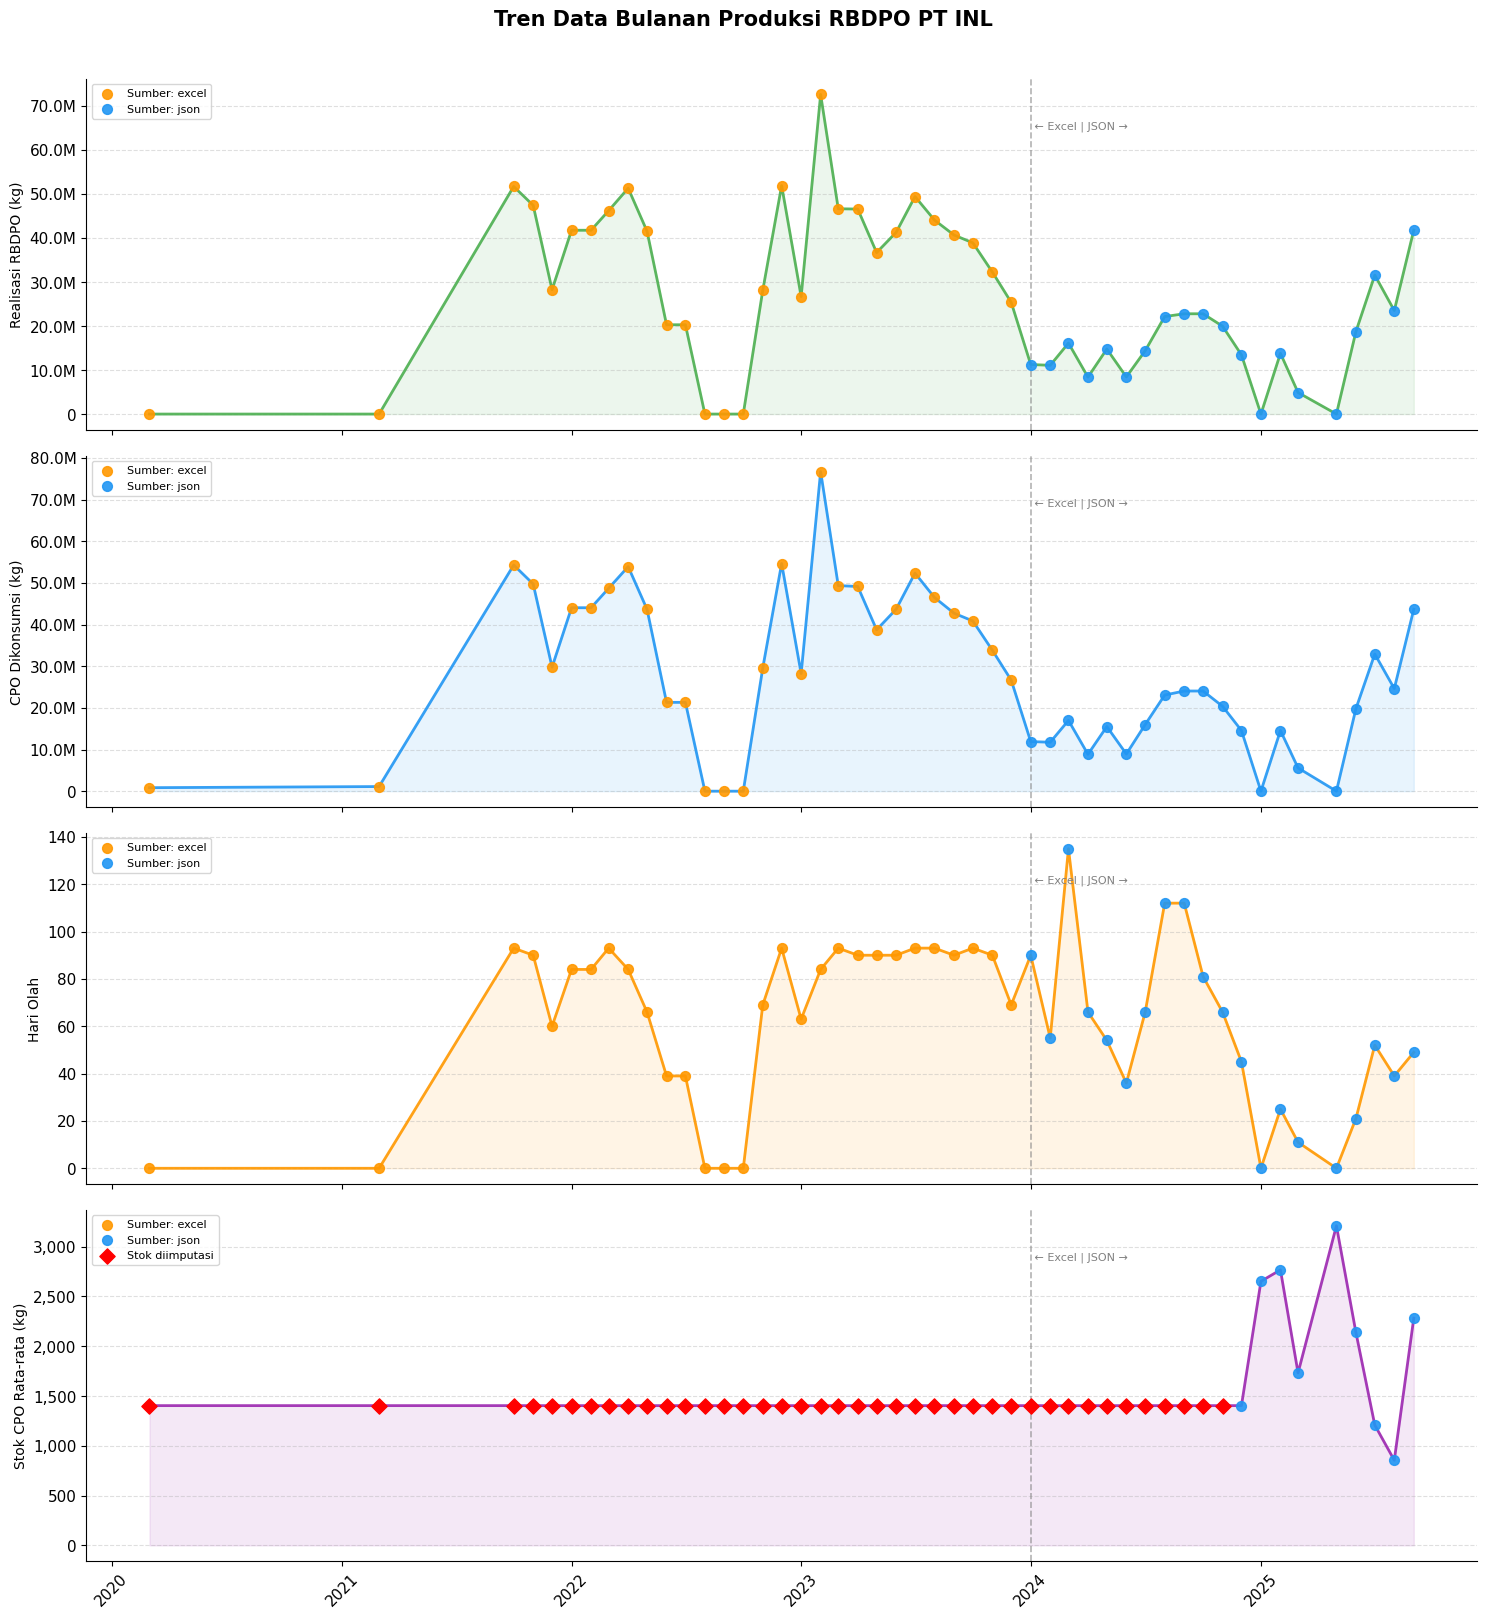

 Grafik tren tersimpan: tren_data.png


In [40]:
# ── 7.2 Tren semua variabel utama ────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)
fig.suptitle('Tren Data Bulanan Produksi RBDPO PT INL',
             fontsize=15, fontweight='bold', y=1.01)

plot_cfg = [
    ('realisasi_rbdpo', 'Realisasi RBDPO (kg)',  '#4CAF50'),
    ('cpo_consume',     'CPO Dikonsumsi (kg)',    '#2196F3'),
    ('hari_olah',       'Hari Olah',              '#FF9800'),
    ('stok_rata2',      'Stok CPO Rata-rata (kg)','#9C27B0'),
]

sumber_color = {'excel': '#FF9800', 'json': '#2196F3'}

for ax, (col, label, color) in zip(axes, plot_cfg):
    ax.plot(df_all['bulan'], df_all[col],
            color=color, linewidth=2, alpha=0.9, zorder=2)
    ax.fill_between(df_all['bulan'], df_all[col], alpha=0.10, color=color)

    # Titik per sumber data
    for src, sc in sumber_color.items():
        mask = df_all['sumber'] == src
        ax.scatter(df_all.loc[mask,'bulan'], df_all.loc[mask,col],
                   color=sc, s=50, zorder=4, alpha=0.9,
                   label=f'Sumber: {src}')

    # Tandai titik imputasi stok
    if col == 'stok_rata2':
        imp = df_all[df_all['stok_imputed']]
        ax.scatter(imp['bulan'], imp[col], marker='D',
                   color='red', s=60, zorder=5, label='Stok diimputasi')

    # Garis vertikal pemisah sumber
    if df_all['sumber'].nunique() > 1:
        batas = df_all[df_all['sumber']=='json']['bulan'].min()
        ax.axvline(batas, color='gray', linewidth=1.2, linestyle='--', alpha=0.6)
        ax.text(batas, ax.get_ylim()[1]*0.85 if ax.get_ylim()[1]>0 else 1,
                ' ← Excel | JSON →', fontsize=8, color='gray')

    ax.set_ylabel(label, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M' if x>=1e6 else f'{x:,.0f}'))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('tren_data.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Grafik tren tersimpan: tren_data.png')


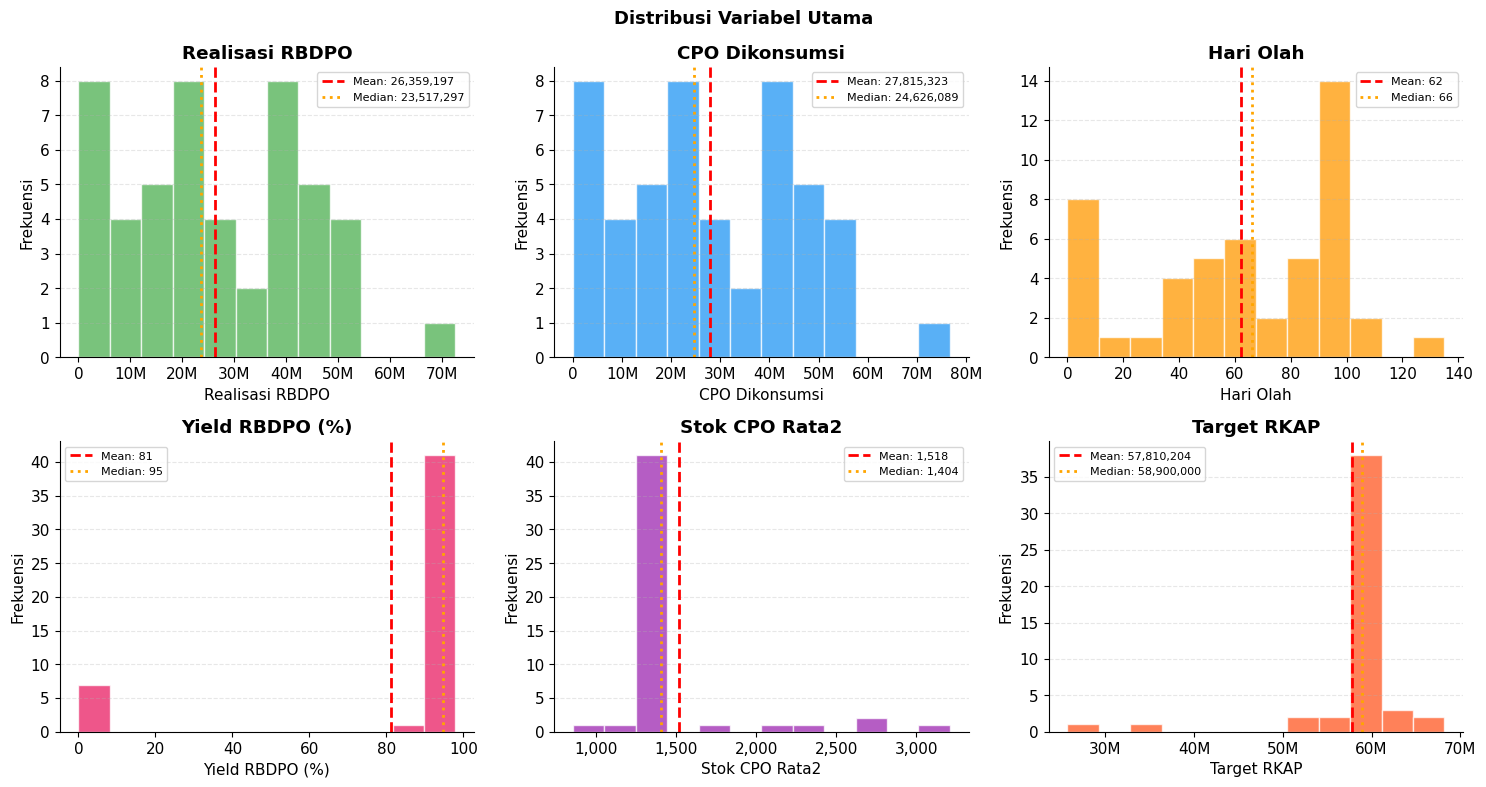

In [16]:
# ── 7.3 Distribusi variabel ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribusi Variabel Utama', fontsize=13, fontweight='bold')

dist_cols = ['realisasi_rbdpo','cpo_consume','hari_olah',
             'yield_rbdpo','stok_rata2','target_rkap']
dist_labels = ['Realisasi RBDPO','CPO Dikonsumsi','Hari Olah',
               'Yield RBDPO (%)','Stok CPO Rata2','Target RKAP']
colors = ['#4CAF50','#2196F3','#FF9800','#E91E63','#9C27B0','#FF5722']

for ax, col, label, color in zip(axes.flat, dist_cols, dist_labels, colors):
    data = df_all[col].dropna()
    ax.hist(data, bins=12, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(data.mean(),   color='red',    linewidth=2, linestyle='--', label=f'Mean: {data.mean():,.0f}')
    ax.axvline(data.median(), color='orange', linewidth=2, linestyle=':',  label=f'Median: {data.median():,.0f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x,_: f'{x/1e6:.0f}M' if abs(x)>=1e6 else f'{x:,.0f}'))
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('distribusi.png', dpi=150, bbox_inches='tight')
plt.show()


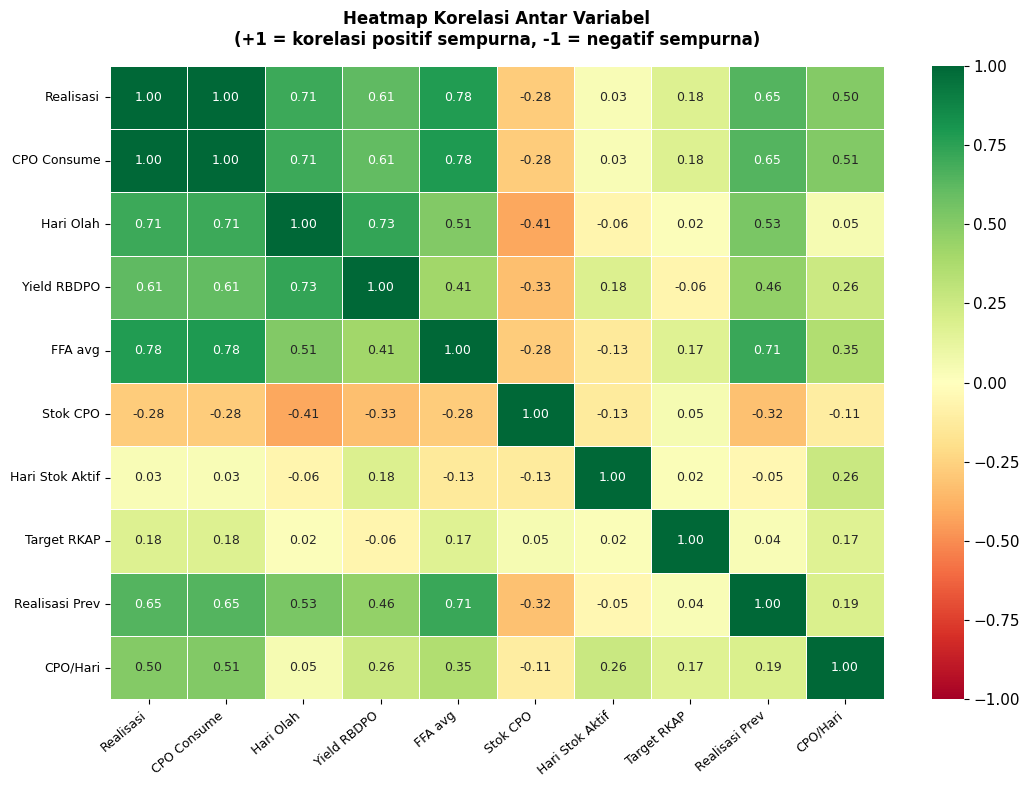


 Korelasi terhadap Realisasi RBDPO (diurutkan):
  CPO Consume         : +0.9999  ▲ ████████████████████████
  FFA avg             : +0.7811  ▲ ███████████████████
  Hari Olah           : +0.7066  ▲ █████████████████
  Realisasi Prev      : +0.6462  ▲ ████████████████
  Yield RBDPO         : +0.6121  ▲ ███████████████
  CPO/Hari            : +0.5038  ▲ ████████████
  Stok CPO            : -0.2757  ▼ ██████
  Target RKAP         : +0.1776  ▲ ████
  Hari Stok Aktif     : +0.0340  ▲ 


In [41]:
# ── 7.4 Heatmap korelasi ─────────────────────────────────────────────────────
CORR_COLS = ['realisasi_rbdpo','cpo_consume','hari_olah','yield_rbdpo',
             'ffa_avg','stok_rata2','stok_hari_aktif','target_rkap',
             'realisasi_prev','cpo_per_hari']
CORR_LABELS = ['Realisasi','CPO Consume','Hari Olah','Yield RBDPO',
               'FFA avg','Stok CPO','Hari Stok Aktif','Target RKAP',
               'Realisasi Prev','CPO/Hari']

corr = df_all[CORR_COLS].corr()
corr.columns = CORR_LABELS
corr.index   = CORR_LABELS

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.zeros_like(corr, dtype=bool)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Heatmap Korelasi Antar Variabel\n(+1 = korelasi positif sempurna, -1 = negatif sempurna)',
             fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Korelasi terhadap Realisasi RBDPO (diurutkan):')
corr_t = corr['Realisasi'].drop('Realisasi').sort_values(key=abs, ascending=False)
for nama, val in corr_t.items():
    bar = '█' * int(abs(val) * 25)
    arah = '▲' if val > 0 else '▼'
    print(f'  {nama:<20}: {val:+.4f}  {arah} {bar}')


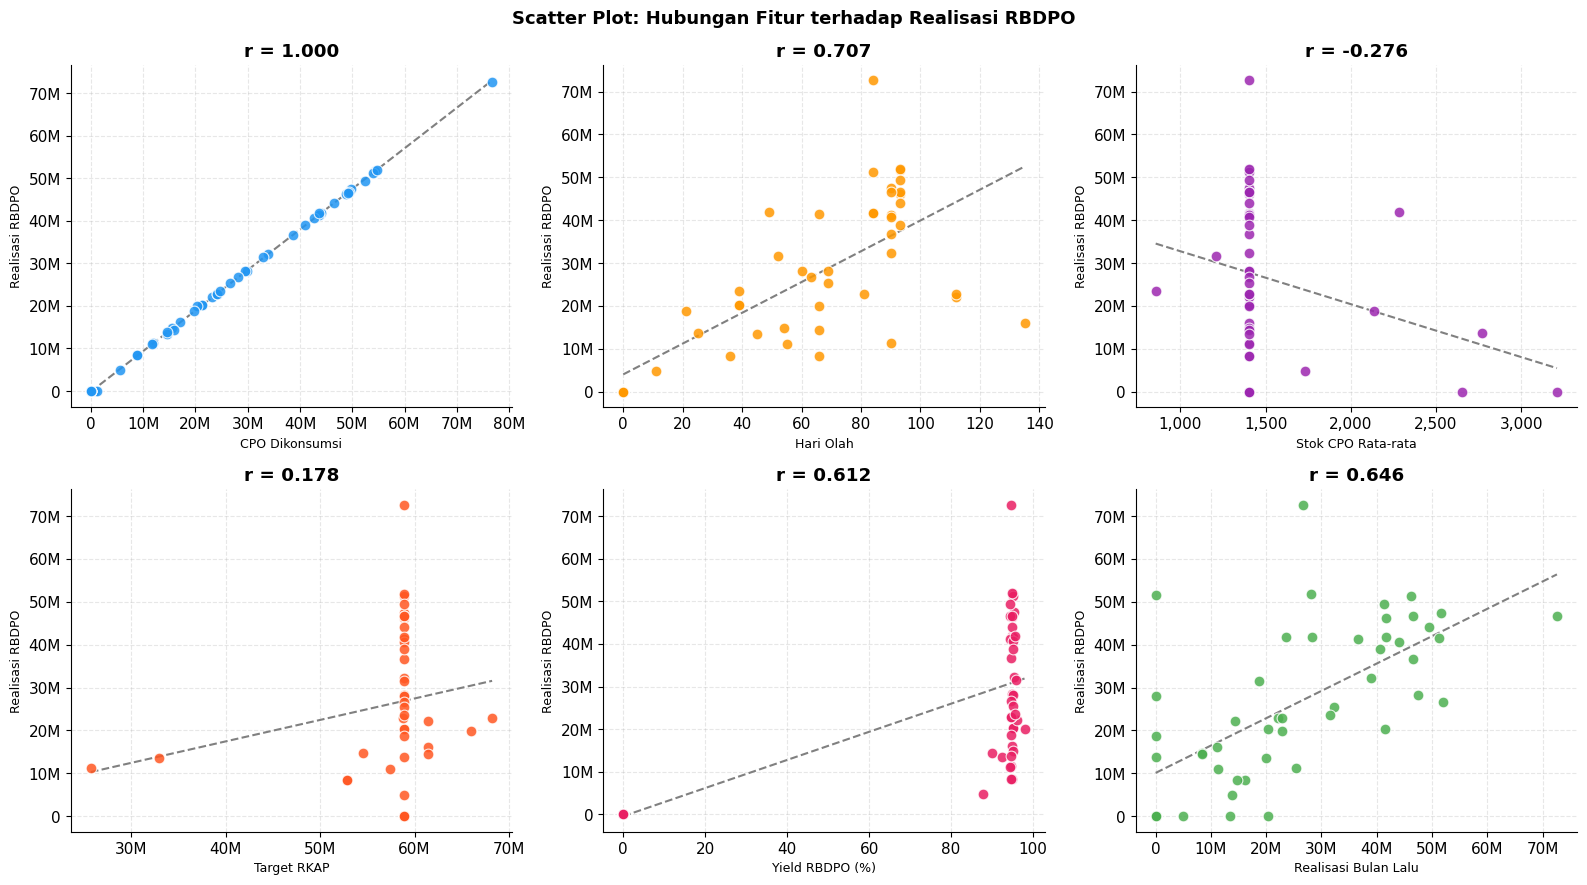

In [42]:
# ── 7.5 Scatter plot fitur vs realisasi ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Scatter Plot: Hubungan Fitur terhadap Realisasi RBDPO',
             fontsize=13, fontweight='bold')

scatter_cols = ['cpo_consume','hari_olah','stok_rata2',
                'target_rkap','yield_rbdpo','realisasi_prev']
scatter_lbl  = ['CPO Dikonsumsi','Hari Olah','Stok CPO Rata-rata',
                'Target RKAP','Yield RBDPO (%)','Realisasi Bulan Lalu']
sc_colors    = ['#2196F3','#FF9800','#9C27B0','#FF5722','#E91E63','#4CAF50']

for ax, col, label, color in zip(axes.flat, scatter_cols, scatter_lbl, sc_colors):
    x = df_all[col].values
    y = df_all['realisasi_rbdpo'].values
    valid = ~np.isnan(x) & ~np.isnan(y)

    ax.scatter(x[valid], y[valid], color=color, s=60,
               edgecolors='white', linewidth=0.8, alpha=0.85, zorder=3)

    # Garis tren
    if valid.sum() > 2:
        z = np.polyfit(x[valid], y[valid], 1)
        p = np.poly1d(z)
        xline = np.linspace(x[valid].min(), x[valid].max(), 100)
        ax.plot(xline, p(xline), '--', color='gray', linewidth=1.5)

    corr_val = np.corrcoef(x[valid], y[valid])[0,1] if valid.sum() > 2 else 0
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Realisasi RBDPO', fontsize=9)
    ax.set_title(f'r = {corr_val:.3f}', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x,_: f'{x/1e6:.0f}M' if abs(x)>=1e6 else f'{x:,.0f}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x,_: f'{x/1e6:.0f}M' if abs(x)>=1e6 else f'{x:,.0f}'))
    ax.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🌲 Cell 8 — Definisi Fitur & Training Random Forest

In [43]:
# ── Definisi fitur model ──────────────────────────────────────────────────────
FITUR = [
    # Fitur utama penelitian (stok bahan baku & target)
    'stok_rata2',        # Rata-rata stok CPO harian
    'stok_max',          # Stok CPO maksimum
    'stok_hari_aktif',   # Hari stok aktif
    'target_rkap',       # Target produksi RKAP
    # Fitur operasional dari laporan produksi
    'cpo_consume',       # Total CPO dikonsumsi
    'hari_olah',         # Hari pabrik beroperasi
    'yield_rbdpo',       # Yield RBDPO (%)
    'pfad_total',        # Produk samping PFAD
    'cpo_per_hari',      # Intensitas produksi per hari
    # Fitur waktu & lag
    'bulan_ke',          # Bulan dalam setahun (1–12)
    'kuartal',           # Kuartal (1–4)
    'realisasi_prev',    # Realisasi bulan sebelumnya
    'cpo_prev',          # CPO consume bulan sebelumnya
    'hari_olah_prev',    # Hari olah bulan sebelumnya
]

NAMA_FITUR = [
    'Stok CPO (rata2)', 'Stok CPO (maks)', 'Hari Stok Aktif', 'Target RKAP',
    'CPO Dikonsumsi', 'Hari Olah', 'Yield RBDPO (%)', 'PFAD Total', 'CPO per Hari',
    'Bulan ke-', 'Kuartal', 'Realisasi Prev', 'CPO Prev', 'Hari Olah Prev',
]

LABEL = 'realisasi_rbdpo'

# Pastikan tidak ada NaN di fitur
df_model = df_all[FITUR + [LABEL, 'bulan', 'sumber', 'stok_imputed']].dropna(subset=FITUR).copy()
df_model = df_model.reset_index(drop=True)

X = df_model[FITUR].values
y = df_model[LABEL].values

print(f' Konfigurasi model:')
print(f'   Jumlah fitur  : {len(FITUR)}')
print(f'   Jumlah sampel : {len(df_model)} bulan')
print(f'   Label         : {LABEL}')
print(f'\n   Fitur yang digunakan:')
for i, (f, n) in enumerate(zip(FITUR, NAMA_FITUR), 1):
    print(f'   {i:2d}. {n:<28} ← kolom: {f}')


 Konfigurasi model:
   Jumlah fitur  : 14
   Jumlah sampel : 49 bulan
   Label         : realisasi_rbdpo

   Fitur yang digunakan:
    1. Stok CPO (rata2)             ← kolom: stok_rata2
    2. Stok CPO (maks)              ← kolom: stok_max
    3. Hari Stok Aktif              ← kolom: stok_hari_aktif
    4. Target RKAP                  ← kolom: target_rkap
    5. CPO Dikonsumsi               ← kolom: cpo_consume
    6. Hari Olah                    ← kolom: hari_olah
    7. Yield RBDPO (%)              ← kolom: yield_rbdpo
    8. PFAD Total                   ← kolom: pfad_total
    9. CPO per Hari                 ← kolom: cpo_per_hari
   10. Bulan ke-                    ← kolom: bulan_ke
   11. Kuartal                      ← kolom: kuartal
   12. Realisasi Prev               ← kolom: realisasi_prev
   13. CPO Prev                     ← kolom: cpo_prev
   14. Hari Olah Prev               ← kolom: hari_olah_prev


In [44]:
# ── Training dengan seluruh data ─────────────────────────────────────────────
rf_final = RandomForestRegressor(
    n_estimators    = 500,
    max_depth       = None,
    min_samples_leaf= 1,
    max_features    = 'sqrt',
    random_state    = SEED,
    n_jobs          = -1
)
rf_final.fit(X, y)

r2_train = rf_final.score(X, y)
y_pred_train = rf_final.predict(X)

print(f' Model Random Forest berhasil dilatih!')
print(f'   n_estimators  : {rf_final.n_estimators}')
print(f'   n_features    : {rf_final.n_features_in_}')
print(f'   max_features  : sqrt({len(FITUR)}) ≈ {int(np.sqrt(len(FITUR)))} fitur per split')
print(f'   R² (training) : {r2_train:.4f}')


 Model Random Forest berhasil dilatih!
   n_estimators  : 500
   n_features    : 14
   max_features  : sqrt(14) ≈ 3 fitur per split
   R² (training) : 0.9825


---
## 📏 Cell 9 — Evaluasi Model (R², RMSE, MAE, MAPE)

In [45]:
print(' Menjalankan Leave-One-Out Cross Validation...')
print(f'   Total iterasi: {len(df_model)} (train={len(df_model)-1}, test=1 per iterasi)\n')

loo = LeaveOneOut()
y_pred_loo = np.zeros(len(y))
y_true_loo = y.copy()

for i, (tr, te) in enumerate(loo.split(X)):
    m = RandomForestRegressor(
        n_estimators=500, random_state=SEED, n_jobs=-1, max_features='sqrt')
    m.fit(X[tr], y[tr])
    y_pred_loo[te] = m.predict(X[te])
    if (i+1) % 10 == 0 or (i+1) == len(df_model):
        print(f'   Iterasi {i+1:3d}/{len(df_model)} selesai...')

# ── Hitung metrik ─────────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_true_loo, y_pred_loo)
rmse = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))
r2   = r2_score(y_true_loo, y_pred_loo)
mask = y_true_loo > 0
mape = np.mean(np.abs((y_true_loo[mask]-y_pred_loo[mask])/(y_true_loo[mask]+1e-9)))*100

print('\n' + '='*55)
print('    HASIL EVALUASI MODEL — LOOCV')
print('='*55)
print(f'  Jumlah data    : {len(df_model)} bulan')
print(f'  MAE            : {mae:>18,.2f} kg')
print(f'  RMSE           : {rmse:>18,.2f} kg')
print(f'  R²             : {r2:>18.4f}')
print(f'  MAPE*          : {mape:>17.2f}%  (* bulan produksi > 0)')
print('='*55)

# Interpretasi otomatis
if r2 >= 0.75:
    interp = ' SANGAT BAIK — model menjelaskan >75% variansi'
elif r2 >= 0.5:
    interp = ' BAIK — model menjelaskan >50% variansi'
elif r2 >= 0.3:
    interp = ' CUKUP — model menjelaskan >30% variansi'
elif r2 >= 0:
    interp = ' LEMAH — model lebih baik dari prediksi rata-rata'
else:
    interp = ' PERLU PERBAIKAN — R² negatif'
print(f'\n  Interpretasi R²: {interp}')

if mape <= 10:
    interp_mape = ' Sangat akurat (MAPE < 10%)'
elif mape <= 20:
    interp_mape = ' Akurat (MAPE < 20%)'
elif mape <= 30:
    interp_mape = ' Cukup akurat (MAPE < 30%)'
else:
    interp_mape = ' Perlu peningkatan data'
print(f'  Interpretasi MAPE: {interp_mape}')


 Menjalankan Leave-One-Out Cross Validation...
   Total iterasi: 49 (train=48, test=1 per iterasi)

   Iterasi  10/49 selesai...
   Iterasi  20/49 selesai...
   Iterasi  30/49 selesai...
   Iterasi  40/49 selesai...
   Iterasi  49/49 selesai...

    HASIL EVALUASI MODEL — LOOCV
  Jumlah data    : 49 bulan
  MAE            :       3,743,805.80 kg
  RMSE           :       6,559,309.72 kg
  R²             :             0.8651
  MAPE*          :             14.60%  (* bulan produksi > 0)

  Interpretasi R²:  SANGAT BAIK — model menjelaskan >75% variansi
  Interpretasi MAPE:  Akurat (MAPE < 20%)


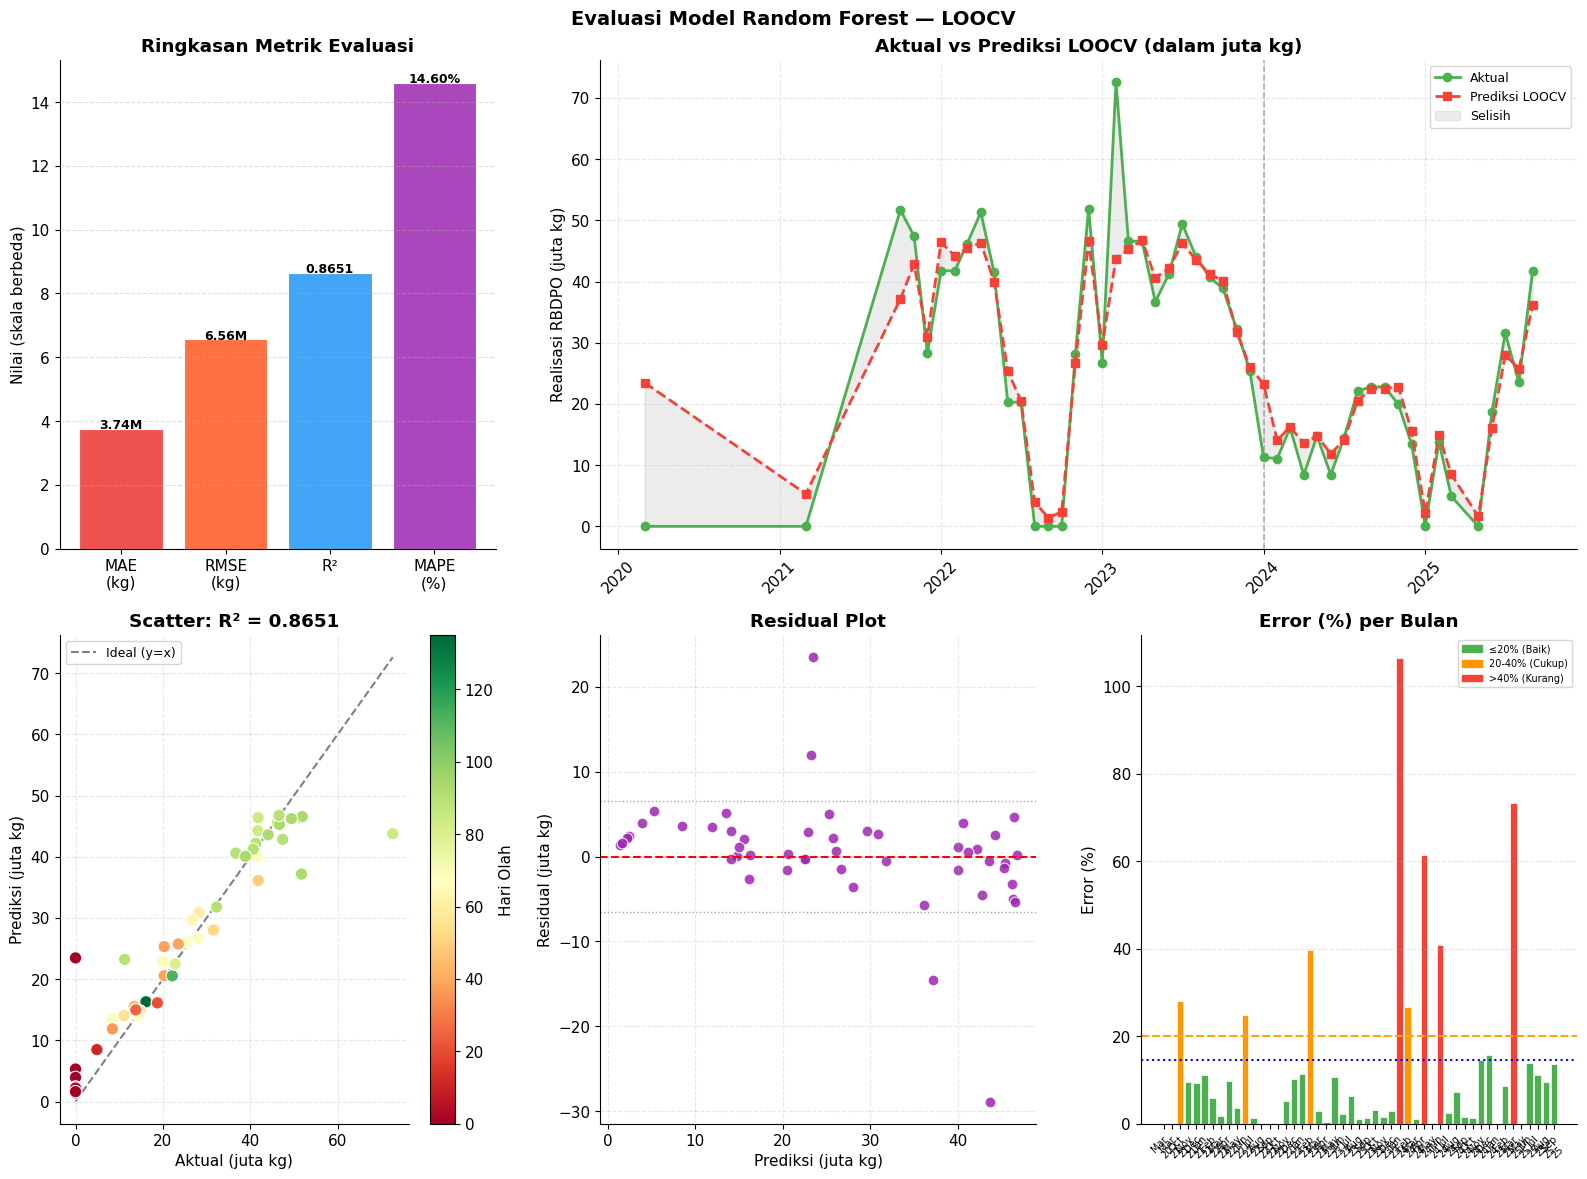

 Grafik evaluasi tersimpan: evaluasi_model.png


In [22]:
# ── Visualisasi metrik evaluasi ───────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Evaluasi Model Random Forest — LOOCV', fontsize=14, fontweight='bold')

# ── Plot 1: Metrik bar chart ──────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
metrik_names = ['MAE\n(kg)', 'RMSE\n(kg)', 'R²', 'MAPE\n(%)']
metrik_vals  = [mae/1e6, rmse/1e6, r2, mape]  # MAE & RMSE dalam juta
metrik_colors= ['#EF5350','#FF7043','#42A5F5','#AB47BC']
bars = ax1.bar(metrik_names, [mae/1e6, rmse/1e6, r2*10, mape],
               color=metrik_colors, edgecolor='white', linewidth=0.8)
for bar, val, orig in zip(bars, [mae/1e6, rmse/1e6, r2*10, mape],
                                 [f'{mae/1e6:.2f}M', f'{rmse/1e6:.2f}M', f'{r2:.4f}', f'{mape:.2f}%']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             orig, ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Ringkasan Metrik Evaluasi', fontweight='bold')
ax1.set_ylabel('Nilai (skala berbeda)')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Plot 2: Tren aktual vs prediksi ──────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, (2,3))
ax2.plot(df_model['bulan'], y_true_loo/1e6, 'o-',
         color='#4CAF50', linewidth=2, markersize=6, label='Aktual', zorder=3)
ax2.plot(df_model['bulan'], y_pred_loo/1e6, 's--',
         color='#F44336', linewidth=2, markersize=6, label='Prediksi LOOCV', zorder=3)
# Shading error
ax2.fill_between(df_model['bulan'], y_true_loo/1e6, y_pred_loo/1e6,
                 alpha=0.15, color='gray', label='Selisih')
# Garis pemisah sumber
if df_model['sumber'].nunique() > 1:
    batas = df_model[df_model['sumber']=='json']['bulan'].min()
    ax2.axvline(batas, color='gray', linewidth=1.2, linestyle='--', alpha=0.6)
ax2.set_title('Aktual vs Prediksi LOOCV (dalam juta kg)', fontweight='bold')
ax2.set_ylabel('Realisasi RBDPO (juta kg)')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=9)
ax2.grid(linestyle='--', alpha=0.3)

# ── Plot 3: Scatter aktual vs prediksi ───────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 4)
sc = ax3.scatter(y_true_loo/1e6, y_pred_loo/1e6,
                 c=df_model['hari_olah'], cmap='RdYlGn',
                 s=80, edgecolors='white', linewidth=0.8, zorder=3)
plt.colorbar(sc, ax=ax3, label='Hari Olah')
mn = min(y_true_loo.min(), y_pred_loo.min())/1e6
mx = max(y_true_loo.max(), y_pred_loo.max())/1e6
ax3.plot([mn,mx],[mn,mx],'--',color='gray',linewidth=1.5,label='Ideal (y=x)')
ax3.set_xlabel('Aktual (juta kg)')
ax3.set_ylabel('Prediksi (juta kg)')
ax3.set_title(f'Scatter: R² = {r2:.4f}', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(linestyle='--', alpha=0.3)

# ── Plot 4: Residual plot ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 5)
residuals = y_pred_loo - y_true_loo
ax4.scatter(y_pred_loo/1e6, residuals/1e6,
            color='#9C27B0', s=60, edgecolors='white', linewidth=0.8, alpha=0.85)
ax4.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax4.axhline(residuals.std()/1e6,  color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax4.axhline(-residuals.std()/1e6, color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax4.set_xlabel('Prediksi (juta kg)')
ax4.set_ylabel('Residual (juta kg)')
ax4.set_title('Residual Plot', fontweight='bold')
ax4.grid(linestyle='--', alpha=0.3)

# ── Plot 5: Error per bulan ───────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 6)
errors_pct = np.where(y_true_loo > 0,
                      np.abs(y_true_loo-y_pred_loo)/(y_true_loo+1e-9)*100, 0)
colors_err = ['#4CAF50' if e <= 20 else '#FF9800' if e <= 40 else '#F44336' for e in errors_pct]
ax5.bar(df_model['bulan'].dt.strftime('%b\n%y'), errors_pct,
        color=colors_err, edgecolor='white', linewidth=0.5)
ax5.axhline(20, color='orange', linewidth=1.5, linestyle='--', label='20% threshold')
ax5.axhline(mape, color='blue', linewidth=1.5, linestyle=':', label=f'MAPE={mape:.1f}%')
ax5.set_title('Error (%) per Bulan', fontweight='bold')
ax5.set_ylabel('Error (%)')
ax5.tick_params(axis='x', rotation=45, labelsize=7)
ax5.legend(fontsize=8)
ax5.grid(axis='y', linestyle='--', alpha=0.3)
# Legend warna
p1 = mpatches.Patch(color='#4CAF50', label='≤20% (Baik)')
p2 = mpatches.Patch(color='#FF9800', label='20-40% (Cukup)')
p3 = mpatches.Patch(color='#F44336', label='>40% (Kurang)')
ax5.legend(handles=[p1,p2,p3], fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('evaluasi_model.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Grafik evaluasi tersimpan: evaluasi_model.png')


In [50]:
print(' Detail evaluasi per bulan:')
display(df_eval.style
    .format({'Aktual (kg)':'{:,.0f}', 'Prediksi (kg)':'{:,.0f}',
             'Selisih (kg)':'{:,.0f}', 'Error (%)':'{:.2f}%'})
    .map(color_error, subset=['Error (%)'])          # ← applymap → map
    .set_caption(f'Evaluasi LOOCV — MAE={mae/1e6:.2f}M | RMSE={rmse/1e6:.2f}M | R²={r2:.4f} | MAPE={mape:.2f}%'))

 Detail evaluasi per bulan:


,Bulan,Sumber,Aktual (kg),Prediksi (kg),Selisih (kg),Error (%)
0,Mar 2020,excel,0,"23,467,294","23,467,294",0.00%
1,Mar 2021,excel,0,"5,305,381","5,305,381",0.00%
2,Oct 2021,excel,"51,703,800","37,173,943","-14,529,857",28.10%
3,Nov 2021,excel,"47,408,400","42,842,688","-4,565,712",9.63%
4,Dec 2021,excel,"28,253,650","30,876,001","2,622,351",9.28%
5,Jan 2022,excel,"41,759,500","46,396,755","4,637,255",11.10%
6,Feb 2022,excel,"41,759,500","44,237,799","2,478,299",5.93%
7,Mar 2022,excel,"46,213,430","45,441,303","-772,127",1.67%
8,Apr 2022,excel,"51,312,240","46,336,773","-4,975,467",9.70%
9,May 2022,excel,"41,537,420","40,001,944","-1,535,476",3.70%


---
## 🏆 Cell 10 — Feature Importance (MDI + Permutation)

In [51]:
print(' Menghitung Feature Importance...')

# ── MDI (bawaan RF) ───────────────────────────────────────────────────────────
fi_mdi = pd.DataFrame({
    'Fitur'  : NAMA_FITUR,
    'MDI'    : rf_final.feature_importances_,
}).sort_values('MDI', ascending=False).reset_index(drop=True)
fi_mdi['MDI (%)']      = (fi_mdi['MDI'] * 100).round(2)
fi_mdi['Kumulatif (%)']= fi_mdi['MDI (%)'].cumsum().round(2)

# ── Permutation Importance ────────────────────────────────────────────────────
perm = permutation_importance(
    rf_final, X, y, n_repeats=50, random_state=SEED, n_jobs=-1)
fi_perm = pd.DataFrame({
    'Fitur' : NAMA_FITUR,
    'Perm'  : perm.importances_mean,
    'Std'   : perm.importances_std,
}).sort_values('Perm', ascending=False).reset_index(drop=True)

print('\n FEATURE IMPORTANCE (MDI):')
display(fi_mdi[['Fitur','MDI (%)','Kumulatif (%)']])
top80 = fi_mdi[fi_mdi['Kumulatif (%)'] <= 80]['Fitur'].tolist()
print(f'\n Fitur yang berkontribusi ≥80% pertama: {top80}')


 Menghitung Feature Importance...

 FEATURE IMPORTANCE (MDI):


,Fitur,MDI (%),Kumulatif (%)
0,CPO Dikonsumsi,24.62,24.62
1,PFAD Total,19.82,44.44
2,Hari Olah,11.77,56.21
3,CPO Prev,11.35,67.56
4,Realisasi Prev,9.89,77.45
5,Yield RBDPO (%),8.13,85.58
6,CPO per Hari,7.84,93.42
7,Hari Olah Prev,2.35,95.77
8,Bulan ke-,1.41,97.18
9,Kuartal,0.96,98.14



 Fitur yang berkontribusi ≥80% pertama: ['CPO Dikonsumsi', 'PFAD Total', 'Hari Olah', 'CPO Prev', 'Realisasi Prev']


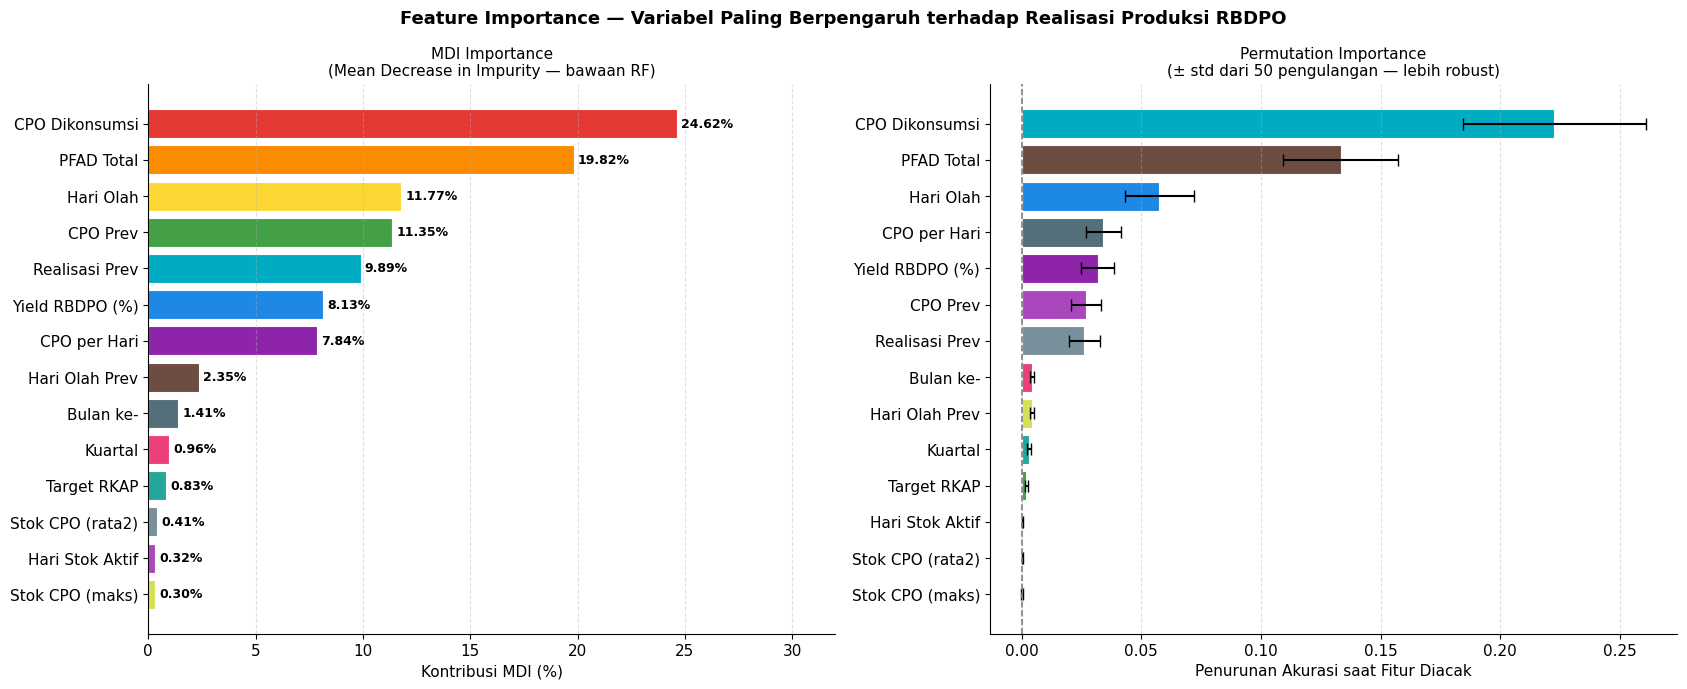

 Grafik feature importance tersimpan: feature_importance.png


In [52]:
# ── Visualisasi Feature Importance ───────────────────────────────────────────
WARNA = ['#E53935','#FB8C00','#FDD835','#43A047','#00ACC1',
         '#1E88E5','#8E24AA','#6D4C41','#546E7A','#EC407A',
         '#26A69A','#78909C','#AB47BC','#D4E157']

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Feature Importance — Variabel Paling Berpengaruh terhadap Realisasi Produksi RBDPO',
             fontsize=13, fontweight='bold')

# ── MDI Importance ────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(fi_mdi['Fitur'], fi_mdi['MDI (%)'],
               color=WARNA[:len(fi_mdi)], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, fi_mdi['MDI (%)']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Kontribusi MDI (%)', fontsize=11)
ax.set_title('MDI Importance\n(Mean Decrease in Impurity — bawaan RF)', fontsize=11)
ax.set_xlim(0, fi_mdi['MDI (%)'].max() * 1.3)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.invert_yaxis()

# ── Permutation Importance ────────────────────────────────────────────────────
ax = axes[1]
fi_p   = fi_perm.sort_values('Perm', ascending=True)
c_perm = [WARNA[NAMA_FITUR.index(f)] for f in fi_p['Fitur']]
ax.barh(fi_p['Fitur'], fi_p['Perm'], xerr=fi_p['Std'],
        color=c_perm, edgecolor='white', linewidth=0.8,
        error_kw={'elinewidth':1.5, 'capsize':4})
ax.axvline(x=0, color='gray', linewidth=1.2, linestyle='--')
ax.set_xlabel('Penurunan Akurasi saat Fitur Diacak', fontsize=11)
ax.set_title('Permutation Importance\n(± std dari 50 pengulangan — lebih robust)', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Grafik feature importance tersimpan: feature_importance.png')


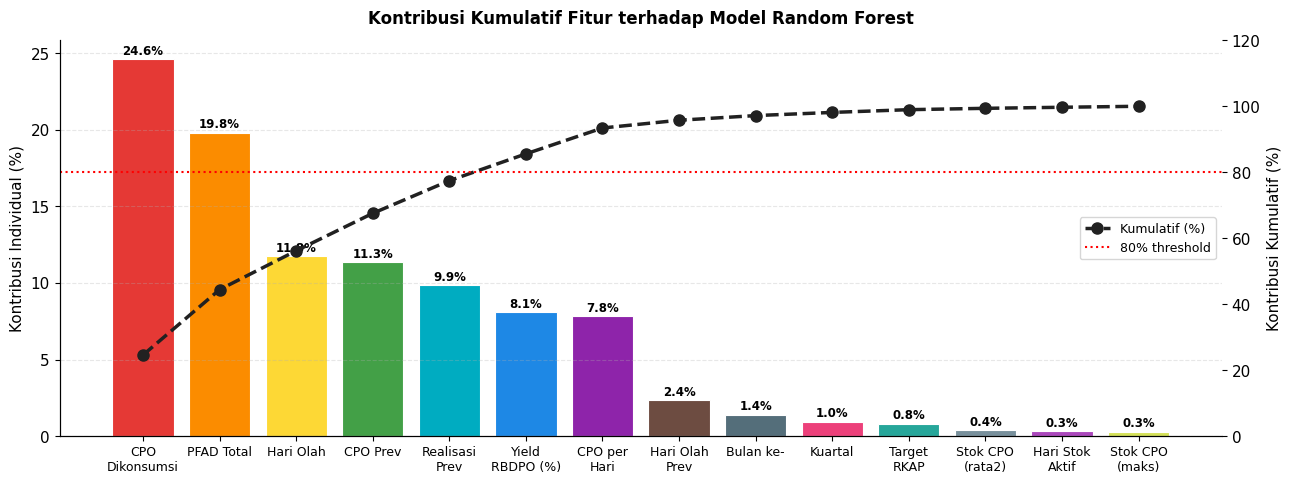

In [25]:
# ── Kontribusi kumulatif ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))  # lebih lebar untuk memberi ruang label

bars = ax.bar(fi_mdi['Fitur'], fi_mdi['MDI (%)'],
              color=WARNA[:len(fi_mdi)], edgecolor='white', linewidth=0.8)

ax2 = ax.twinx()
ax2.plot(fi_mdi['Fitur'], fi_mdi['Kumulatif (%)'],
         'o--', color='#212121', linewidth=2.5, markersize=8, label='Kumulatif (%)')
ax2.axhline(y=80, color='red', linewidth=1.5, linestyle=':', label='80% threshold')
ax2.set_ylim(0, 120)
ax2.set_ylabel('Kontribusi Kumulatif (%)', fontsize=11)
ax2.legend(loc='center right', fontsize=9)

# Label nilai di atas bar
for bar, val in zip(bars, fi_mdi['MDI (%)']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}%',
            ha='center', fontsize=8.5, fontweight='bold')

ax.set_ylabel('Kontribusi Individual (%)', fontsize=11)
ax.set_title('Kontribusi Kumulatif Fitur terhadap Model Random Forest',
             fontsize=12, fontweight='bold', pad=12)

# ── Kunci perbaikan: wrap teks label x-axis ───────────────────────────────────
import textwrap
wrapped_labels = [
    textwrap.fill(label, width=10)          # wrap tiap ~10 karakter
    for label in fi_mdi['Fitur']
]
ax.set_xticks(range(len(fi_mdi)))
ax.set_xticklabels(wrapped_labels, fontsize=9, ha='center')  # ha='center' bukan 'right'

ax.grid(axis='y', linestyle='--', alpha=0.3)

# Tambah margin bawah agar label tidak terpotong
fig.subplots_adjust(bottom=0.22)

plt.savefig('kontribusi_kumulatif.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📝 Cell 11 — Ringkasan Akhir

In [53]:
print('=' * 65)
print('      RINGKASAN HASIL PENELITIAN RANDOM FOREST')
print('      Analisis Produksi RBDPO PT Industri Nabati Lestari')
print('=' * 65)

n_excel_data = int((df_model['sumber']=='excel').sum()) if 'sumber' in df_model.columns else 0
n_json_data  = int((df_model['sumber']=='json').sum()) if 'sumber' in df_model.columns else len(df_model)

print(f'\n Dataset')
print(f'   Sumber         : Excel Daily Report (2021–2023) + JSON API (2024–2025)')
print(f'   Periode        : {df_model["bulan"].min().strftime("%B %Y")} – {df_model["bulan"].max().strftime("%B %Y")}')
print(f'   Total sampel   : {len(df_model)} bulan')
print(f'   Dari Excel     : {n_excel_data} bulan')
print(f'   Dari JSON      : {n_json_data} bulan')
print(f'   Stok imputasi  : {int(df_model["stok_imputed"].sum())} bulan (interpolasi linear)')
print(f'   Jumlah fitur   : {len(FITUR)}')

print(f'\n Evaluasi Model (Leave-One-Out Cross Validation)')
print(f'   ─────────────────────────────────────────────────')
print(f'   MAE            : {mae:>18,.2f} kg')
print(f'   RMSE           : {rmse:>18,.2f} kg')
print(f'   R²             : {r2:>18.4f}')
print(f'   MAPE           : {mape:>17.2f}% (bulan aktif produksi)')
print(f'   ─────────────────────────────────────────────────')
n_baik = int(np.sum(np.where(y_true_loo>0, np.abs(y_true_loo-y_pred_loo)/(y_true_loo+1e-9)*100, 0) <= 20))
n_aktif= int(np.sum(y_true_loo > 0))
print(f'   Prediksi akurat (error≤20%): {n_baik}/{n_aktif} bulan produksi aktif')

print(f'\n Peringkat Variabel Paling Berpengaruh (MDI)')
print(f'   {"No.":<4} {"Variabel":<28} {"MDI (%)":>10} {"Kumulatif":>12}')
print(f'   {"─"*4} {"─"*28} {"─"*10} {"─"*12}')
for i, row in fi_mdi.iterrows():
    print(f'   {i+1:<4} {row["Fitur"]:<28} {row["MDI (%)"]:.2f}% {row["Kumulatif (%)"]:.2f}%')


      RINGKASAN HASIL PENELITIAN RANDOM FOREST
      Analisis Produksi RBDPO PT Industri Nabati Lestari

 Dataset
   Sumber         : Excel Daily Report (2021–2023) + JSON API (2024–2025)
   Periode        : March 2020 – September 2025
   Total sampel   : 49 bulan
   Dari Excel     : 29 bulan
   Dari JSON      : 20 bulan
   Stok imputasi  : 40 bulan (interpolasi linear)
   Jumlah fitur   : 14

 Evaluasi Model (Leave-One-Out Cross Validation)
   ─────────────────────────────────────────────────
   MAE            :       3,743,805.80 kg
   RMSE           :       6,559,309.72 kg
   R²             :             0.8651
   MAPE           :             14.60% (bulan aktif produksi)
   ─────────────────────────────────────────────────
   Prediksi akurat (error≤20%): 41/42 bulan produksi aktif

 Peringkat Variabel Paling Berpengaruh (MDI)
   No.  Variabel                        MDI (%)    Kumulatif
   ──── ──────────────────────────── ────────── ────────────
   1    CPO Dikonsumsi              